# **HW 3: Bayes-based Classifiers and SVM**
**HW Due date is 03/11/2025, 23:59 pm**

Objective:
* To understand the basics of Naive Bayes, and SVM classifiers.
* To practice building these models using sample datasets.
* To visualize model performance and apply hyperparameter tuning techniques.

In [ ]:
# Load the Cleveland Heart Disease dataset
# Replace 'path_to_your_file.data' with the actual path to your .data file
heart_df = pd.read_csv("processed.cleveland.data", header=None, delimiter=',')
selected_columns = [0, 1, 2, 3, 4, 13] # for now we only use first 5 attributes and target class. You might want to include other attributes to see how the accuracy of the trained models are changing!
heart_df = heart_df.iloc[:, selected_columns]
column_names = ['age', 'sex', 'cp', 'trestbps', 'chol', 'HD']
heart_df.columns = column_names
heart_df['HD'] = (heart_df['HD'] > 0).astype(int) #This line converts the 'HD' column into a binary attribute, where any value greater
 # than 0 is considered as presence of heart disease (1), and 0 otherwise."""

# dataset is from this link: https://archive.ics.uci.edu/dataset/45/heart+disease
#sex: sex (1 = male; 0 = female)
"""cp: chest pain type
-- Value 1: typical angina
-- Value 2: atypical angina
-- Value 3: non-anginal pain
-- Value 4: asymptomatic"""
#trestbps: resting blood pressure (in mm Hg on admission to the hospital)
#chol: serum cholestoral in mg/dl
"""HD: diagnosis of heart disease (angiographic disease status)
-- Value 0: < 50% diameter narrowing
-- Value 1: > 50% diameter narrowing"""

In [3]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC
from pgmpy.models import BayesianNetwork

heart_df = pd.read_csv("processed.cleveland.data", header=None, delimiter=',')
selected_columns = [0, 1, 2, 3, 4, 13] # for now we only use first 5 attributes and target class. You might want to include other attributes to see how the accuracy of the trained models are changing!
heart_df = heart_df.iloc[:, selected_columns]
column_names = ['age', 'sex', 'cp', 'trestbps', 'chol', 'HD']
heart_df.columns = column_names
heart_df['HD'] = (heart_df['HD'] > 0).astype(int) #This line converts the 'HD' column into a binary attribute, where any value greater
 # than 0 is considered as presence of heart disease (1), and 0 otherwise."""

# Splitting features and target
X = heart_df.drop(columns=['HD'])
y = heart_df['HD']

# Splitting data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Standardizing the features
## Your code starts here
scaler = StandardScaler()
x_train = scaler.fit_transform(X_train)
x_test = scaler.transform(X_test)
## Your code ends here

Use Naive Bayes classifier to get a model.

In [4]:
# Step 3: Initial Evaluation with Naive Bayes
## Your code starts here
# Train Naive Bayes Classifier
naivebayes_classifier = GaussianNB()
naivebayes_classifier.fit(x_train, y_train)

# Prediction
y_pred = naivebayes_classifier.predict(x_test)

# Evaluate
from sklearn.metrics import accuracy_score, classification_report

accuracy = accuracy_score(y_test, y_pred)

print(f"Naive Bayes Accuracy: {accuracy:.10f}")
print(classification_report(y_test, y_pred))
## Your code ends here

Naive Bayes Accuracy: 0.6721311475
              precision    recall  f1-score   support

           0       0.66      0.66      0.66        29
           1       0.69      0.69      0.69        32

    accuracy                           0.67        61
   macro avg       0.67      0.67      0.67        61
weighted avg       0.67      0.67      0.67        61



**Question:** I got an accuracy of 67.2%. What can you do to improve on that using Naive Bayes Classifier?

**Answer:** I can apply feature scaling, balance the dataset, or use kernel density estimation.

Correlation Matrix:
               age       sex        cp  trestbps      chol        HD
age       1.000000 -0.097542  0.104139  0.284946  0.208950  0.223120
sex      -0.097542  1.000000  0.010084 -0.064456 -0.199915  0.276816
cp        0.104139  0.010084  1.000000 -0.036077  0.072319  0.414446
trestbps  0.284946 -0.064456 -0.036077  1.000000  0.130120  0.150825
chol      0.208950 -0.199915  0.072319  0.130120  1.000000  0.085164
HD        0.223120  0.276816  0.414446  0.150825  0.085164  1.000000


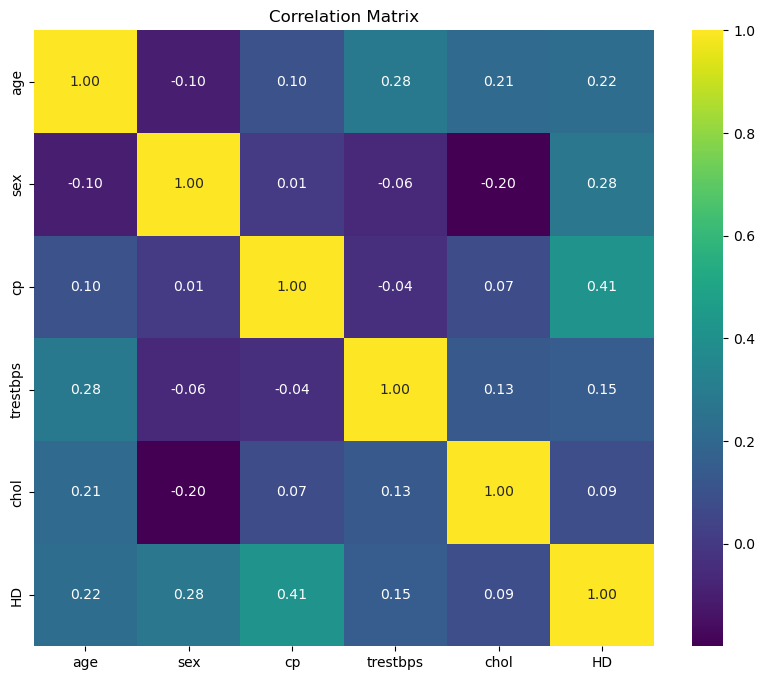

In [7]:
import pandas as pd

# Generate the correlation matrix
## Your code starts here
correlation_matrix = heart_df.corr()
## Your code ends here

# Display the correlation matrix
print("Correlation Matrix:")
print(correlation_matrix)

# You can also visualize the correlation matrix for better interpretation
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='viridis', fmt=".2f")
plt.title('Correlation Matrix')
plt.show()

Now, Apply SVM models to the same dataset!

In [15]:
# Import necessary libraries
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.svm import SVC
from sklearn.metrics import classification_report, accuracy_score
import numpy as np
import matplotlib.pyplot as plt

# Comparison with SVM Classifiers: apply linear and a non-linear SVM classifiers
# Linear SVM
## Your code starts here
linear_svm = SVC(kernel = 'linear')
linear_svm.fit(x_train, y_train)
linear_svm_accuracy = linear_svm.score(x_test, y_test)
## Your code ends here
print("Linear SVM Accuracy:", linear_svm_accuracy)

# Non-Linear SVM (RBF Kernel)
## Your code starts here
nonlinear_svm = SVC(kernel = 'rbf')
nonlinear_svm.fit(x_train, y_train)
nonlinear_svm_accuracy = nonlinear_svm.score(x_test, y_test)
## Your code ends here
print("Non-linear SVM Accuracy:", nonlinear_svm_accuracy)

# Task 3: Exploring Different Kernels
kernels = ['poly', 'rbf', 'sigmoid']
for kernel in kernels:
## Your code starts here
    svm_model = SVC(kernel = kernel)
    svm_model.fit(x_train, y_train)
    y_pred = svm_model.predict(x_test)

    print(f"\nSVM Classifier with {kernel.capitalize()} Kernel Metrics:")
    print(classification_report(y_test, y_pred))
    print(f"Accuracy: {accuracy_score(y_test, y_pred):.10f}\n")
## Your code ends here

# Task 4: Hyperparameter Tuning: Use GridSearchCV to find the best hyperparameters and print them out
param_grid = {'C': [0.1, 1, 10, 100], 'gamma': [1, 0.1, 0.01, 0.001]}
svm_classifier = SVC(kernel='rbf')
grid_search = GridSearchCV(svm_classifier, param_grid, cv = 5, scoring = 'accuracy') ## Your code starts here
grid_search.fit(x_train, y_train)

print("Best Hyperparameters:", grid_search.best_params_, "\n")

# Train best model
best_svm = grid_search.best_estimator_
y_pred_best = best_svm.predict(x_test)

# Evaluation
print("Tuned SVM Classifier Metrics:")
print(classification_report(y_test, y_pred_best))
print("Accuracy:", accuracy_score(y_test, y_pred_best))
## Your code ends here

Linear SVM Accuracy: 0.7377049180327869
Non-linear SVM Accuracy: 0.7704918032786885

SVM Classifier with Poly Kernel Metrics:
              precision    recall  f1-score   support

           0       0.91      0.72      0.81        29
           1       0.79      0.94      0.86        32

    accuracy                           0.84        61
   macro avg       0.85      0.83      0.83        61
weighted avg       0.85      0.84      0.83        61

Accuracy: 0.8360655738


SVM Classifier with Rbf Kernel Metrics:
              precision    recall  f1-score   support

           0       0.78      0.72      0.75        29
           1       0.76      0.81      0.79        32

    accuracy                           0.77        61
   macro avg       0.77      0.77      0.77        61
weighted avg       0.77      0.77      0.77        61

Accuracy: 0.7704918033


SVM Classifier with Sigmoid Kernel Metrics:
              precision    recall  f1-score   support

           0       0.63      0.

# Submission Guidelines:

* Implement the above steps in a Jupyter Notebook file.
* Save your ipython code and name it as: lastname_firstname_HW3.ipynb (.ipynb extension)
* Include comments and explanations to describe your approach and the rationale behind each step.
* Submit on Canvas.